In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(100))

541


In [8]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


D = delta_qexp(545) 
print(nth_prime(100))
print(D[nth_prime(100)])

PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
541
-1695266465052058


In [4]:
sum?

Signature:      sum(expression, *args, **kwds)
Docstring:     
Return the symbolic sum \sum_{v = a}^b expression with respect to the
variable v with endpoints a and b.

INPUT:

* "expression" -- a symbolic expression

* "v" -- a variable or variable name

* "a" -- lower endpoint of the sum

* "b" -- upper endpoint of the sum

* "algorithm" -- (default: "'maxima'")  one of

  * "'maxima'" -- use Maxima (the default)

  * "'maple'" -- (optional) use Maple

  * "'mathematica'" -- (optional) use Mathematica

  * "'giac'" -- (optional) use Giac

  * "'sympy'" -- use SymPy

EXAMPLES:

   sage: k, n = var('k,n')
   sage: sum(k, k, 1, n).factor()
   1/2*(n + 1)*n

   sage: sum(1/k^4, k, 1, oo)
   1/90*pi^4

   sage: sum(1/k^5, k, 1, oo)
   zeta(5)


  This function only works with symbolic expressions. To sum any other
  objects like list elements or function return values, please use
  python summation, see
  http://docs.python.org/library/functions.html#sumIn particular, this
  does not work

In [12]:
add([1,2])

3

In [22]:
from sage.all import *


def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

j_list=[1,2,3]
test1=h_sequence_from_j(j_list)
print(test1)
test2=j_sequence_from_h(test1)
print(test2)
print("============================================")
j_list=[2,3,5,7,11]
test1=h_sequence_from_j(j_list)
print(test1)
test2=j_sequence_from_h(test1)
print(test2)

[1, 1, 3/2, 13/6]
[1, 2, 3]
[1, 2, 7/2, 6, 79/8, 321/20]
[2, 3, 5, 7, 11]


deformed_h_list[0]: 1
n: 1 elapsed: 0.0004378835360209147
n: 2 elapsed: 0.0004770000775655111
n: 3 elapsed: 0.0004851818084716797
n: 4 elapsed: 0.0004950165748596191
n: 5 elapsed: 0.00051193634668986
n: 6 elapsed: 0.0005310853322347005
n: 7 elapsed: 0.0005603988965352376
n: 8 elapsed: 0.0005971153577168782
n: 9 elapsed: 0.000642700990041097
n: 10 elapsed: 0.0006967663764953613
n: 11 elapsed: 0.0007555842399597168
n: 12 elapsed: 0.0008149822552998861
n: 13 elapsed: 0.0008916497230529785
n: 14 elapsed: 0.0010007659594217936
n: 15 elapsed: 0.0011019349098205567
n: 16 elapsed: 0.0012150168418884276
n: 17 elapsed: 0.0013524969418843588
n: 18 elapsed: 0.0014963308970133463
n: 19 elapsed: 0.0016522010167439778
n: 20 elapsed: 0.0018138647079467773
n: 21 elapsed: 0.0019962151845296225
n: 22 elapsed: 0.0022074302037556966
n: 23 elapsed: 0.0024316827456156414
n: 24 elapsed: 0.0026529828707377114
n: 25 elapsed: 0.002910800774892171
n: 26 elapsed: 0.003204902013142904
n: 27 elapsed: 0.0035093665122

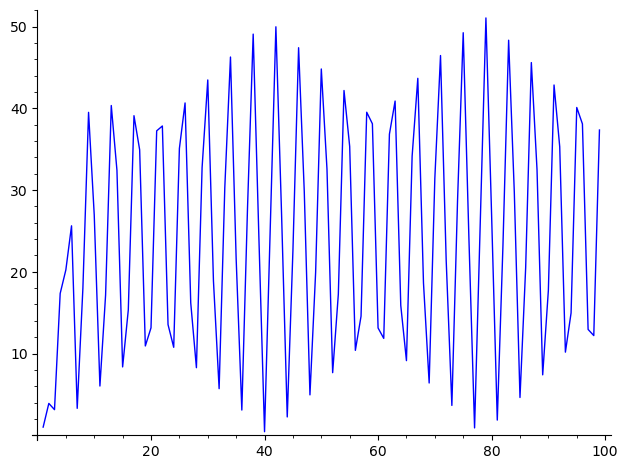

In [25]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(545) 
h_list=[1]+[D[nth_prime(k)] for k in range(1,101)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,100):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run15may26no1.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run15may26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run15may26no3.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)






In [27]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


deformed_h_list[0]: 1
n: 1 elapsed: 0.05102768341700236
n: 2 elapsed: 0.051045616467793785
n: 3 elapsed: 0.0510501503944397
n: 4 elapsed: 0.05105760097503662
n: 5 elapsed: 0.05106896956761678
n: 6 elapsed: 0.051084268093109134
n: 7 elapsed: 0.05110863447189331
n: 8 elapsed: 0.051143519083658856
n: 9 elapsed: 0.0511772354443868
n: 10 elapsed: 0.05121793349583944
n: 11 elapsed: 0.051266018549601236
n: 12 elapsed: 0.05132338603337606
n: 13 elapsed: 0.05139266649881999
n: 14 elapsed: 0.05148640076319377
n: 15 elapsed: 0.05157143672307332
n: 16 elapsed: 0.05167109966278076
n: 17 elapsed: 0.05179118315378825
n: 18 elapsed: 0.0519264817237854
n: 19 elapsed: 0.05207981665929159
n: 20 elapsed: 0.05223535299301148
n: 21 elapsed: 0.0524115522702535
n: 22 elapsed: 0.05261798699696859
n: 23 elapsed: 0.05283515055974324
n: 24 elapsed: 0.053051253159840904
n: 25 elapsed: 0.05330196619033813
n: 26 elapsed: 0.053588302930196126
n: 27 elapsed: 0.053884987036387125
n: 28 elapsed: 0.054205818970998125
n: 

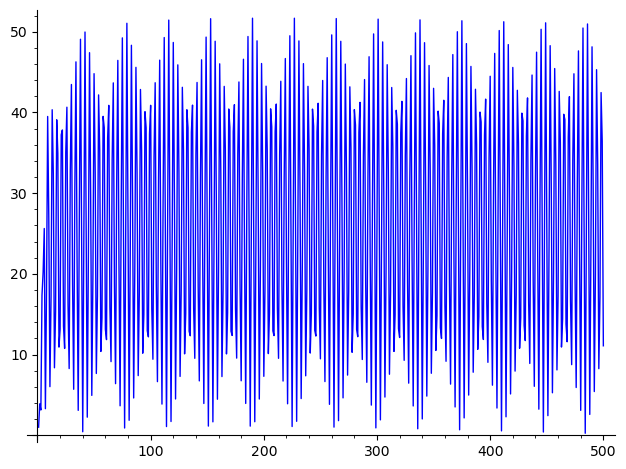

In [29]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(4000) 
h_list=[1]+[D[nth_prime(k)] for k in range(1,501)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run15may26no4.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run15may26no5.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run15may26no6.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run15may26no7.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)

In [30]:
with open('/Users/barrybrent/data2/run15may26no14.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run15may26no15.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run15may26no16.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run15may26no17.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run15may26no18.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)

In [32]:
lc=len(chi_list)
print(lc)

500


In [34]:
chi_list_a=chi_list[:300]
with open('/Users/barrybrent/data2/run15may26no17a.txt', 'wb') as wfile:
    pickle.dump(chi_list_a, wfile)

In [35]:
chi_list_b=chi_list[301:400]
with open('/Users/barrybrent/data2/run15may26no17b.txt', 'wb') as wfile:
    pickle.dump(chi_list_b, wfile)

In [36]:
chi_list_c=chi_list[401:450]
with open('/Users/barrybrent/data2/run15may26no17c.txt', 'wb') as wfile:
    pickle.dump(chi_list_c, wfile)

In [39]:
chi_list_d=chi_list[450:480]
with open('/Users/barrybrent/data2/run15may26no17d.txt', 'wb') as wfile:
    pickle.dump(chi_list_d, wfile)

In [40]:
chi_list_e=chi_list[481:500]
with open('/Users/barrybrent/data2/run15may26no17e.txt', 'wb') as wfile:
    pickle.dump(chi_list_e, wfile)

Data range: n = 1 to 500
Number of data points: 500
Min modulus range: 0.251094 to 51.682877

Detrending: Savitzky-Golay filter, window = 31, poly order = 3
  lag-1 autocorrelation of residuals = 0.0388
  Detrended data std dev: 13.9168

AR(1) lag-1 autocorrelation (rho): 0.0388
Frequency bins tested: 247
Bonferroni-corrected per-bin alpha: 95% -> 0.000202,  99% -> 0.000040

SIGNIFICANT PERIODICITIES  (period <= N/3 = 167, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            4.10   0.244000     1.32e+07   99%

  Only one significant peak (period = 4.10); no ratios to compute.


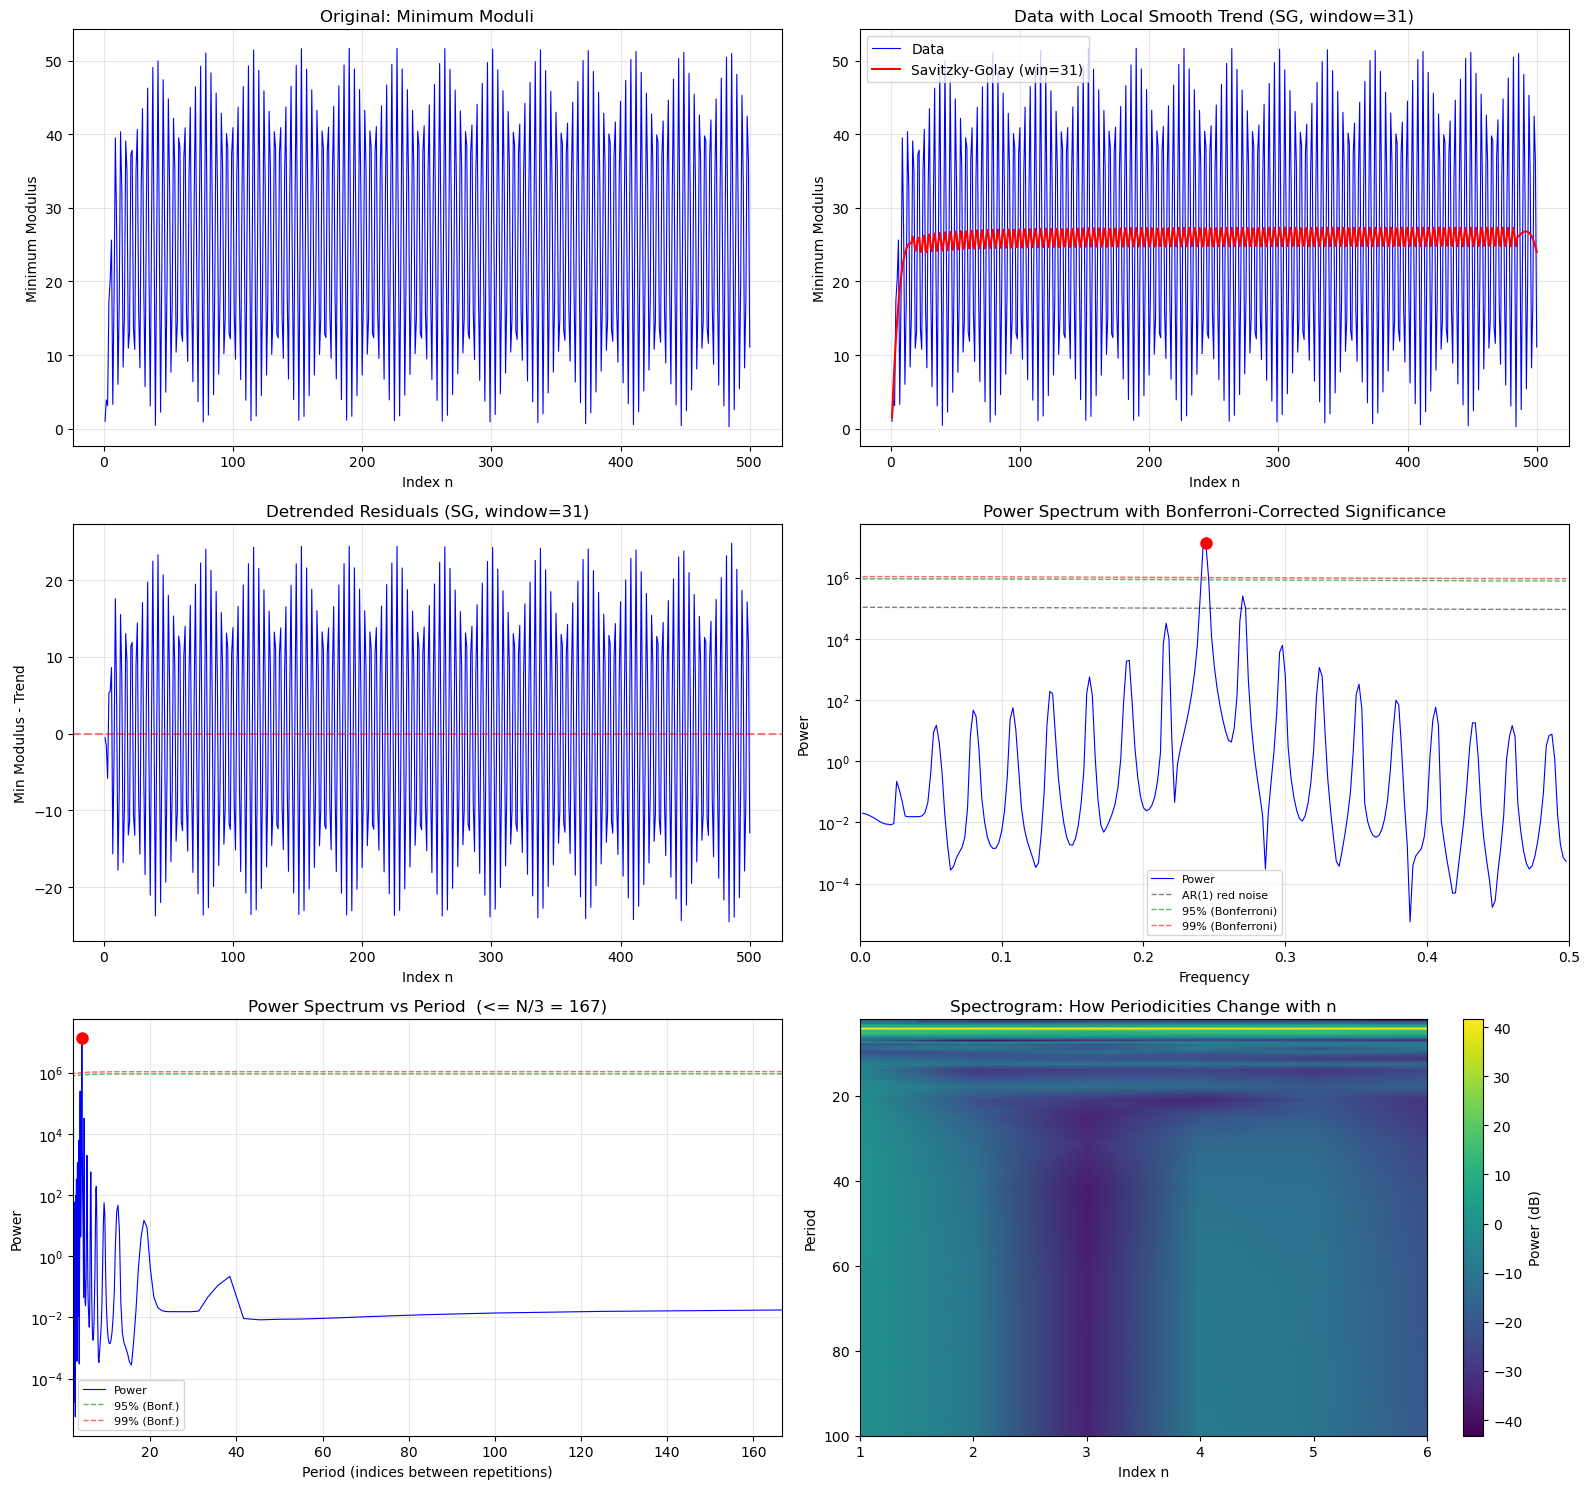


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run15may26no6.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)

# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v4)
#
# Key fix in this version: MULTIPLE TESTING CORRECTION.
#
# With N/2 ~ 175 frequency bins, a 95% single-bin threshold will produce
# ~9 false positives purely by chance, even for white noise. Previous
# versions didn't account for this, so plateau noise peaks were
# incorrectly flagged as "significant periodicities."
#
# This version applies a Bonferroni correction: the per-bin significance
# level is divided by the number of independent frequency bins tested,
# so the *family-wise* false positive rate stays at 5% (or 1%).
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. LOCAL SMOOTHING DETREND  (Savitzky-Golay)
# ==============================================================================
sg_poly_order = 3

candidate_windows = [w for w in range(21, min(N//2, 151), 10) if w % 2 == 1]

best_win, best_score = candidate_windows[0], np.inf
sg_results = {}
for win in candidate_windows:
    trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
    resid = minmoduli - trend
    r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    sg_results[win] = (trend, resid, r1)
    if r1 < best_score:
        best_score = r1
        best_win = win

smooth_trend, detrended, _ = sg_results[best_win]

print(f"\nDetrending: Savitzky-Golay filter, window = {best_win}, poly order = {sg_poly_order}")
print(f"  lag-1 autocorrelation of residuals = {best_score:.4f}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
max_credible_period = N / 3.0
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
# Per-bin alpha = family_alpha / n_tests
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

print("\n" + "="*75)
print(f"SIGNIFICANT PERIODICITIES  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
    # Period ratios: fundamental (rank 1) to each subsequent peak
    if len(significant_peaks) >= 2:
        fund_idx = significant_peaks[0][0]
        fund_period = periods[fund_idx]
        print(f"\n{'':>6}PERIOD RATIOS  (fundamental / peak)")
        print(f"{'':>6}Fundamental period: {fund_period:.2f}")
        print(f"{'':>6}{'-'*55}")
        print(f"{'':>6}{'Rank':<6} {'Period':<12} {'T_fund / T_peak':<18} {'Nearest int':<12}")
        print(f"{'':>6}{'-'*55}")
        for rank, (pi, level) in enumerate(significant_peaks[1:15], 2):
            ratio = fund_period / periods[pi]
            nearest = round(ratio)
            print(f"{'':>6}{rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     {nearest:>6}")
    elif len(significant_peaks) == 1:
        print(f"\n  Only one significant peak (period = {periods[significant_peaks[0][0]]:.2f}); "
              f"no ratios to compute.")
else:
    print("  No peaks exceed the Bonferroni-corrected significance threshold.")
    print("  --> The data has no statistically significant periodicity.")
    print("  (Period ratios are not computed when no peaks are significant.)")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=f'Savitzky-Golay (win={best_win})')
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Local Smooth Trend (SG, window={best_win})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals (SG, window={best_win})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)


